# Appendix 3.2: Dose-Concentration Pharmacokinetics

This notebook reviews the additional example of shelving estimating functions with a one-compartment IV bolus model for drug concentration.
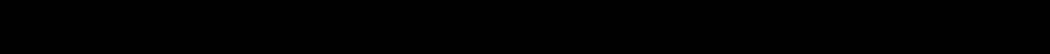
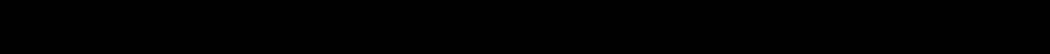

In [1]:
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import delicatessen as deli
from delicatessen import MEstimator
from delicatessen.estimating_equations import ee_regression
from delicatessen.utilities import inverse_logit, aggregate_efuncs

print("Versions")
print("NumPy:       ", np.__version__)
print("SciPy:       ", sp.__version__)
print("Pandas:      ", pd.__version__)
print("Matplotlib:  ", mpl.__version__)
print("Delicatessen:", deli.__version__)

Versions
NumPy:        2.3.5
SciPy:        1.16.3
Pandas:       2.3.3
Matplotlib:   3.10.8
Delicatessen: 4.3


In [2]:
d = pd.read_csv("data/warfarin.csv")
d['intercept'] = 1
d['dose'] = d.groupby('id')['amt'].transform('max')
d['concentration'] = d['dv']
d = d.loc[(d['dvid'] == 'cp') & (d['time'] >= 1.)].copy()

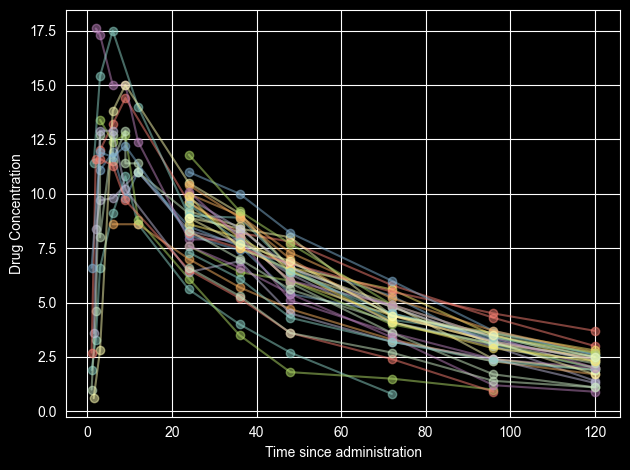

In [3]:
# Plotting trajectories for each unit
unique_ids = np.unique(d['id'])
for uid in unique_ids:
    ds = d.loc[d['id'] == uid].copy()
    plt.plot(ds['time'], ds['dv'], 'o-', alpha=0.5)

plt.xlabel("Time since administration")
plt.ylabel("Drug Concentration")
plt.tight_layout()

In [4]:
def psi_1bolus_pk(theta):
    v_inv = theta[0]
    v = 1 / np.exp(v_inv)
    k_neg = theta[1]
    k = -k_neg
    half_life = theta[2]
    clearance = theta[3]
    n = d.shape[0]

    # IV bolus model estimating function
    ee_ivb = ee_regression(theta=[v_inv, k_neg], y=np.log(d['dv']), X=d[['intercept', 'time']],
                          model='linear', offset=np.log(d['dose']))

    # Half-life estimating function
    ee_hlife = (np.log(2) / k - half_life) * np.ones(n)

    # Clearance estimating function
    ee_clr = (v*k - clearance) * np.ones(n)

    return np.vstack([ee_ivb, ee_hlife, ee_clr])

def psi_pk(theta):
    return aggregate_efuncs(psi_1bolus_pk(theta), group=d['id'])

In [5]:
estr = MEstimator(psi_1bolus_pk, init=[-2., 0.1, 1., 1.])
estr.estimate()
estr.print_results(decimals=3)

              Estimation Method: M-estimator
--------------------------------------------------------------
No. Observations:         247 | No. Parameters:              4
Solving algorithm:         lm | Max Iterations:           5000
Solving tolerance:      1e-09 | Allow P-Inverse:             1
Derivative Method:     approx | Deriv Approx:            1e-09
Small N Correction:      None | Distribution:           Z-stat
   Theta   StdErr  Z-score      LCL      UCL  P-value  S-value 
--------------------------------------------------------------
  -2.212    0.061  -36.390   -2.332   -2.093    0.000  960.755 
  -0.014    0.001  -17.041   -0.016   -0.013    0.000  213.908 
  48.207    2.829   17.041   42.663   53.752    0.000  213.908 
   0.131    0.003   38.445    0.125    0.138    0.000      inf 


In [6]:
estr = MEstimator(psi_pk, init=[-2., 0.1, 1., 1.])
estr.estimate()
estr.print_results(decimals=3)

              Estimation Method: M-estimator
--------------------------------------------------------------
No. Observations:          32 | No. Parameters:              4
Solving algorithm:         lm | Max Iterations:           5000
Solving tolerance:      1e-09 | Allow P-Inverse:             1
Derivative Method:     approx | Deriv Approx:            1e-09
Small N Correction:      None | Distribution:           Z-stat
   Theta   StdErr  Z-score      LCL      UCL  P-value  S-value 
--------------------------------------------------------------
  -2.212    0.075  -29.556   -2.359   -2.066    0.000  635.371 
  -0.014    0.001  -16.855   -0.016   -0.013    0.000  209.334 
  48.207    2.860   16.855   42.602   53.813    0.000  209.334 
   0.131    0.007   19.705    0.118    0.144    0.000  284.719 
